# Classification Chats vs Chiens : CNN from scratch vs Transfer Learning

## Introduction
L'objectif de ce travail est de comparer deux approches de classification d'images sur le jeu de données Cats vs Dogs : un réseau de neurones convolutif (CNN) entraîné entièrement à partir de zéro (from scratch), et un modèle pré-entraîné adapté à notre problème par transfert d'apprentissage (transfer learning). La comparaison porte sur la vitesse de convergence, les performances obtenues (accuracy, précision, recall) et la robustesse des deux modèles.

## 1. Environnement de travail

Les expériences ont été réalisées sur Google Colab. L'entraînement d'un réseau convolutif sur plusieurs milliers d'images étant coûteux en calcul, nous utilisons un processeur graphique (GPU NVIDIA T4). La cellule suivante vérifie que le GPU est bien disponible ; tous les calculs (modèle et données) seront effectués sur ce périphérique.

In [3]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cuda


### Reproductibilité

L'entraînement d'un réseau de neurones fait intervenir de nombreuses sources d'aléatoire : initialisation des poids, ordre de présentation des images, transformations aléatoires. Afin de garantir la reproductibilité des résultats, nous fixons la graine (seed) de l'ensemble des générateurs aléatoires utilisés (Python, NumPy et PyTorch). Cette graine est réinitialisée avant chaque entraînement, de sorte que les différentes configurations comparées partent exactement des mêmes conditions initiales.

In [4]:
import random
import numpy as np

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print("Seed fixé :", SEED)

Seed fixé : 42


## 2. Préparation des données

Nous utilisons le jeu de données Dogs vs Cats issu de Kaggle, dans une version déjà organisée en deux dossiers : un dossier d'entraînement (22 500 images) et un dossier de test (2 500 images). Chacun contient un sous-dossier par classe (cat et dog), ce qui permet un étiquetage automatique des images à partir du nom du dossier. Les données sont téléchargées directement dans l'environnement Colab et ne sont pas versionnées sur GitHub.

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
%cd /content/drive/MyDrive/Deep_learning/cnn_cat_dog_image_classification

[Errno 2] No such file or directory: '/content/drive/MyDrive/Deep_learning/cnn_cat_dog_image_classification'
/content


In [7]:
%ls

drive/  sample_data/


In [8]:
%ls /content/drive/MyDrive


'Aicha_Codou_Arab_Ly (1).xlsx'
'Aicha Codou Arab Ly CV.pdf'
'Aicha Codou Arab Ly.ipynb'
'Aïcha Codou Arab Ly Professional Minimalist CV Resume.pdf.pdf.pdf'
 Aicha_Codou_Arab_Ly.xlsx
'Colab Notebooks'/
'Examen machine learning'/
 image.jpg
 IMG_3078.png
"le gibco c'est du liquide.gsheet"
'Milieux de culture pour bactéries.gsheet'
 players_22.csv
'Rapport Devoir NoSQL - Architecture MongoDB Ongaku.gdoc'
'Récapitulatif Milieux Culture Microbiologie.gsheet'
'TP Aicha Codou Arab LY'/


In [9]:
%cd /content
!wget -q https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip
!unzip -q Cat_Dog_data.zip
%ls

/content
Cat_Dog_data/  Cat_Dog_data.zip  drive/  __MACOSX/  sample_data/


### Transformations des images

Les images du jeu de données sont de tailles variables, alors qu'un réseau de neurones nécessite des entrées de dimension fixe. Nous définissons donc deux chaînes de transformations :

- **Données d'entraînement** : nous appliquons une augmentation de données (recadrage aléatoire redimensionné en 224×224, retournement horizontal aléatoire, rotation aléatoire de ±15°). Cette technique expose le modèle à des variantes différentes de chaque image à chaque époque, ce qui limite le sur-apprentissage et améliore la capacité de généralisation.
- **Données de validation et de test** : aucune transformation aléatoire n'est appliquée afin d'évaluer le modèle sur des images non modifiées. Les images sont simplement redimensionnées puis recadrées au centre en 224×224.

Dans les deux cas, les images sont converties en tenseurs puis normalisées à l'aide de la moyenne et de l'écart-type du jeu de données ImageNet. Cette normalisation est indispensable pour le modèle pré-entraîné, et elle est également appliquée au CNN from scratch afin que la comparaison soit équitable.

In [10]:
from torchvision import datasets, transforms

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_transforms = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("Transformations prêtes")

Transformations prêtes


### Séparation entraînement / validation

Le dossier d'entraînement est divisé aléatoirement (avec une graine fixe) en deux sous-ensembles : 80 % des images (18 000) servent à l'entraînement et 20 % (4 500) à la validation. L'ensemble de validation permet de suivre les performances du modèle à chaque époque sur des images qu'il n'a jamais vues, de comparer les optimiseurs et de sélectionner le meilleur modèle. Le jeu de test (2 500 images) est quant à lui réservé à l'évaluation finale : il n'est utilisé qu'une seule fois, ce qui garantit une estimation non biaisée des performances.

In [11]:
from torch.utils.data import Subset

data_dir = '/content/Cat_Dog_data'

train_full = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
val_full   = datasets.ImageFolder(data_dir + '/train', transform=test_transforms)
test_data  = datasets.ImageFolder(data_dir + '/test',  transform=test_transforms)

indices = torch.randperm(len(train_full), generator=torch.Generator().manual_seed(SEED)).tolist()

n_val = int(0.2 * len(indices))
val_idx   = indices[:n_val]
train_idx = indices[n_val:]

train_data = Subset(train_full, train_idx)
val_data   = Subset(val_full, val_idx)

print("Classes :", train_full.class_to_idx)
print("Train      :", len(train_data), "images")
print("Validation :", len(val_data), "images")
print("Test       :", len(test_data), "images")

Classes : {'cat': 0, 'dog': 1}
Train      : 18000 images
Validation : 4500 images
Test       : 2500 images


### Chargement des données par lots (DataLoaders)

Les images sont fournies au modèle par batches de 64 images grâce aux DataLoaders de PyTorch. Pour l'entraînement, les images sont mélangées à chaque époque (shuffle), afin que le modèle ne voie pas les exemples toujours dans le même ordre, ce qui favorise une meilleure convergence. Pour la validation et le test, l'ordre est conservé, car il n'influence pas l'évaluation.

In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Vérification : on prend un seul paquet
images, labels = next(iter(train_loader))
print("Forme du paquet d'images :", images.shape)
print("Étiquettes :", labels[:20])

Forme du paquet d'images : torch.Size([64, 3, 224, 224])
Étiquettes : tensor([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0])


## 3. Expérience A : CNN entraîné from scratch

### Architecture
Le réseau est composé de quatre blocs convolutionnels successifs. Chaque bloc applique une convolution 3×3, une normalisation par lots (Batch Normalization), une fonction d'activation ReLU et un sous-échantillonnage par max-pooling 2×2. Le nombre de filtres double à chaque bloc (32, 64, 128 puis 256) tandis que la résolution spatiale est divisée par deux (224 → 112 → 56 → 28 → 14). Les premiers blocs détectent des motifs simples (contours, textures), les suivants des structures plus complexes (formes, parties d'animaux).

Un Global Average Pooling réduit ensuite chaque carte de caractéristiques à une seule valeur, puis un classifieur composé de deux couches entièrement connectées produit les scores des deux classes.

### Justification de la Batch Normalization et du Dropout
- **Batch Normalization** : elle est placée après chaque convolution, avant l'activation ReLU. Elle normalise les activations de chaque lot, ce qui stabilise leur distribution au fil de l'entraînement. Cela permet d'utiliser des taux d'apprentissage plus élevés, accélère la convergence et rend le réseau moins sensible à l'initialisation des poids.
- **Dropout** : il est placé uniquement dans le classifieur final. C'est dans les couches entièrement connectées que se concentre le risque de sur-apprentissage. En désactivant aléatoirement une partie des neurones pendant l'entraînement, le Dropout empêche le réseau de dépendre de quelques neurones particuliers et l'oblige à apprendre des représentations plus robustes. Il n'est pas utilisé dans les couches convolutionnelles, où la Batch Normalization joue déjà un rôle de régularisation et où les deux techniques combinées peuvent se perturber mutuellement.

In [13]:
import torch.nn as nn

class ScratchCNN(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()

        def bloc(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=3, padding=1),
                nn.BatchNorm2d(c_out),
                nn.ReLU(),
                nn.MaxPool2d(2),
            )

        # Extrait les caractéristiques de l'image
        self.features = nn.Sequential(
            bloc(3, 32),
            bloc(32, 64),
            bloc(64, 128),
            bloc(128, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Décision : chat ou chien
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

# Test
model = ScratchCNN().to(device)
sortie = model(images.to(device))
print("Forme de la sortie :", sortie.shape)
print("Nombre de paramètres :", sum(p.numel() for p in model.parameters()))

Forme de la sortie : torch.Size([64, 2])
Nombre de paramètres : 422530


## 4. Entraînement et évaluation

### Métriques de suivi
À chaque époque, nous calculons sur les données d'entraînement et de validation :
- **loss** (entropie croisée), qui mesure l'erreur que le modèle cherche à minimiser ;
- **accuracy**, la proportion d'images correctement classées ;
- **précision**, la proportion d'images prédites « chien » qui sont réellement des chiens ;
- **recall** (rappel), la proportion de vrais chiens que le modèle a bien reconnus.

La classe « chien » est considérée comme la classe positive. La précision et le recall complètent l'accuracy : ils indiquent si le modèle a tendance à confondre les classes dans un sens plutôt que dans l'autre.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def run_epoch(model, loader, criterion, optimizer=None):
    """Entraîne le modèle si on donne un optimizer, sinon l'évalue seulement."""
    entrainement = optimizer is not None
    model.train() if entrainement else model.eval()

    total_loss = 0
    vrais, predits = [], []

    with torch.set_grad_enabled(entrainement):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            sorties = model(images)
            loss = criterion(sorties, labels)

            if entrainement:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            vrais.extend(labels.cpu().numpy())
            predits.extend(sorties.argmax(1).cpu().numpy())

    return {
        'loss':      total_loss / len(vrais),
        'accuracy':  accuracy_score(vrais, predits),
        'precision': precision_score(vrais, predits, zero_division=0),
        'recall':    recall_score(vrais, predits, zero_division=0),
    }

# Test
criterion = nn.CrossEntropyLoss()
print(run_epoch(model, val_loader, criterion))

{'loss': 0.6939003546502855, 'accuracy': 0.49844444444444447, 'precision': 0.49844444444444447, 'recall': 1.0}


### Procédure d'entraînement
À chaque époque, le modèle est entraîné sur l'ensemble d'entraînement puis évalué sur l'ensemble de validation. Les métriques sont enregistrées afin de tracer les courbes d'apprentissage.

Le taux d'apprentissage (learning rate) est ajusté au cours de l'entraînement par un scheduler **CosineAnnealingLR**, qui le fait décroître progressivement selon une courbe en cosinus. Un taux élevé en début d'entraînement permet de progresser rapidement, tandis qu'un taux faible en fin d'entraînement permet d'affiner les poids sans osciller autour du minimum.

À chaque amélioration de l'accuracy de validation, les poids du modèle sont sauvegardés dans un fichier `.pt`. Nous conservons ainsi le meilleur modèle rencontré au cours de l'entraînement, et non simplement le dernier, qui peut être moins bon en cas de sur-apprentissage.

In [15]:
import os, time
import pandas as pd
import torch.optim as optim

SAVE_DIR = '/content/drive/MyDrive/cnn_catsdogs'
os.makedirs(SAVE_DIR + '/checkpoints', exist_ok=True)
os.makedirs(SAVE_DIR + '/results', exist_ok=True)

def fit(nom, model, optimizer, epochs):
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    historique = []
    meilleure_acc = 0
    chemin = f'{SAVE_DIR}/checkpoints/{nom}.pt'

    for epoch in range(1, epochs + 1):
        debut = time.time()
        tr = run_epoch(model, train_loader, criterion, optimizer)
        va = run_epoch(model, val_loader, criterion)
        scheduler.step()

        ligne = {'epoch': epoch}
        ligne.update({'train_' + k: v for k, v in tr.items()})
        ligne.update({'val_' + k: v for k, v in va.items()})
        historique.append(ligne)

        message = ''
        if va['accuracy'] > meilleure_acc:
            meilleure_acc = va['accuracy']
            torch.save(model.state_dict(), chemin)
            message = '-> sauvegardé'

        print(f"[{nom}] Époque {epoch}/{epochs} | "
              f"train loss {tr['loss']:.3f} acc {tr['accuracy']:.3f} | "
              f"val loss {va['loss']:.3f} acc {va['accuracy']:.3f} "
              f"P {va['precision']:.3f} R {va['recall']:.3f} | "
              f"{time.time() - debut:.0f}s {message}")

    historique = pd.DataFrame(historique)
    historique.to_csv(f'{SAVE_DIR}/results/history_{nom}.csv', index=False)
    return historique

print("Fonction fit prête")

Fonction fit prête


### Choix des optimiseurs et du learning rate
Deux optimiseurs sont comparés pour chaque modèle :
- **SGD avec momentum (0,9)** : la descente de gradient stochastique classique. Le momentum accumule une « inertie » dans la direction des gradients précédents, ce qui accélère la convergence et réduit les oscillations. Learning rate initial : 0,01.
- **Adam** : un optimiseur adaptatif qui ajuste automatiquement le pas d'apprentissage de chaque paramètre à partir des moyennes des gradients passés. Il converge généralement plus vite et est moins sensible au choix du learning rate. Learning rate initial : 0,001.

Ces valeurs initiales correspondent aux valeurs de référence couramment utilisées pour chaque optimiseur. Le learning rate est ensuite ajusté automatiquement au cours de l'entraînement par le scheduler CosineAnnealingLR. Un weight decay (régularisation L2) de 1e-4 est ajouté pour limiter le sur-apprentissage.

Avant chaque entraînement, la graine aléatoire est réinitialisée afin que les deux optimiseurs partent de la même initialisation des poids.

In [16]:
set_seed()
model_scratch_sgd = ScratchCNN().to(device)
optimizer = optim.SGD(model_scratch_sgd.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

hist_scratch_sgd = fit('scratch_sgd', model_scratch_sgd, optimizer, epochs=10)

[scratch_sgd] Époque 1/10 | train loss 0.660 acc 0.599 | val loss 0.619 acc 0.649 P 0.615 R 0.791 | 96s -> sauvegardé
[scratch_sgd] Époque 2/10 | train loss 0.632 acc 0.637 | val loss 0.603 acc 0.645 P 0.600 R 0.866 | 95s 
[scratch_sgd] Époque 3/10 | train loss 0.615 acc 0.660 | val loss 0.592 acc 0.676 P 0.636 R 0.816 | 95s -> sauvegardé
[scratch_sgd] Époque 4/10 | train loss 0.602 acc 0.679 | val loss 0.543 acc 0.735 P 0.716 R 0.778 | 95s -> sauvegardé
[scratch_sgd] Époque 5/10 | train loss 0.591 acc 0.684 | val loss 0.537 acc 0.742 P 0.774 R 0.681 | 95s -> sauvegardé
[scratch_sgd] Époque 6/10 | train loss 0.579 acc 0.695 | val loss 0.533 acc 0.729 P 0.685 R 0.844 | 96s 
[scratch_sgd] Époque 7/10 | train loss 0.571 acc 0.703 | val loss 0.504 acc 0.759 P 0.755 R 0.765 | 93s -> sauvegardé
[scratch_sgd] Époque 8/10 | train loss 0.560 acc 0.713 | val loss 0.491 acc 0.770 P 0.800 R 0.716 | 95s -> sauvegardé
[scratch_sgd] Époque 9/10 | train loss 0.550 acc 0.719 | val loss 0.474 acc 0.785 

In [17]:
set_seed()
model_scratch_adam = ScratchCNN().to(device)
optimizer = optim.Adam(model_scratch_adam.parameters(), lr=0.001, weight_decay=1e-4)

hist_scratch_adam = fit('scratch_adam', model_scratch_adam, optimizer, epochs=10)

[scratch_adam] Époque 1/10 | train loss 0.647 acc 0.620 | val loss 0.629 acc 0.653 P 0.646 R 0.669 | 99s -> sauvegardé
[scratch_adam] Époque 2/10 | train loss 0.614 acc 0.660 | val loss 0.552 acc 0.719 P 0.712 R 0.733 | 94s -> sauvegardé
[scratch_adam] Époque 3/10 | train loss 0.593 acc 0.683 | val loss 0.522 acc 0.744 P 0.735 R 0.760 | 94s -> sauvegardé
[scratch_adam] Époque 4/10 | train loss 0.578 acc 0.696 | val loss 0.526 acc 0.732 P 0.701 R 0.806 | 96s 
[scratch_adam] Époque 5/10 | train loss 0.566 acc 0.707 | val loss 0.519 acc 0.754 P 0.736 R 0.789 | 94s -> sauvegardé
[scratch_adam] Époque 6/10 | train loss 0.553 acc 0.720 | val loss 0.545 acc 0.712 P 0.651 R 0.912 | 93s 
[scratch_adam] Époque 7/10 | train loss 0.542 acc 0.727 | val loss 0.479 acc 0.774 P 0.817 R 0.704 | 93s -> sauvegardé
[scratch_adam] Époque 8/10 | train loss 0.523 acc 0.743 | val loss 0.452 acc 0.789 P 0.757 R 0.850 | 96s -> sauvegardé
[scratch_adam] Époque 9/10 | train loss 0.513 acc 0.749 | val loss 0.431 a

## 5. Expérience B : Transfer learning avec ResNet-18

### Principe
Le transfert d'apprentissage consiste à réutiliser un réseau déjà entraîné sur un très grand jeu de données pour résoudre un nouveau problème. Nous utilisons ResNet-18, pré-entraîné sur ImageNet (1,2 million d'images réparties en 1 000 catégories, dont de nombreuses races de chats et de chiens). Les couches convolutionnelles de ce réseau ont déjà appris à extraire des caractéristiques visuelles génériques et pertinentes (contours, textures, formes, parties d'animaux).

### Adaptation du modèle
- Tous les poids du réseau pré-entraîné sont **gelés** : ils ne sont pas modifiés pendant l'entraînement. ResNet-18 sert ainsi d'extracteur de caractéristiques.
- La dernière couche du réseau (qui prédisait 1 000 classes) est remplacée par un **nouveau classifieur** adapté à nos 2 classes : une couche linéaire (512 → 256), une Batch Normalization, une activation ReLU, un Dropout (p = 0,5) et une couche linéaire finale (256 → 2).
- Seul ce nouveau classifieur est entraîné.

Comme pour l'expérience A, la Batch Normalization stabilise l'apprentissage du classifieur et le Dropout limite le sur-apprentissage dans les couches entièrement connectées.

In [18]:
from torchvision import models

def build_resnet(dropout=0.5):

    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)


    for param in model.parameters():
        param.requires_grad = False


    model.fc = nn.Sequential(
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(256, 2),
    )
    return model


model_test = build_resnet().to(device)
print("Forme de la sortie :", model_test(images.to(device)).shape)
total = sum(p.numel() for p in model_test.parameters())
entrainables = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Paramètres au total : {total}")
print(f"Paramètres entraînables : {entrainables}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 113MB/s]


Forme de la sortie : torch.Size([64, 2])
Paramètres au total : 11308866
Paramètres entraînables : 132354


### Entraînement
Le modèle est entraîné avec les deux mêmes optimiseurs que pour l'expérience A (SGD avec momentum, learning rate initial 0,01 ; Adam, learning rate initial 0,001), avec le même scheduler CosineAnnealingLR et le même weight decay. Seuls les paramètres du nouveau classifieur sont transmis à l'optimiseur.

Le nombre d'époques est limité à 5 : le réseau disposant déjà de caractéristiques visuelles pertinentes, seul un petit nombre de paramètres doit être appris, et la convergence est attendue beaucoup plus rapidement que pour le CNN from scratch.

In [19]:

set_seed()
model_tl_sgd = build_resnet().to(device)
optimizer = optim.SGD(model_tl_sgd.fc.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
hist_tl_sgd = fit('tl_sgd', model_tl_sgd, optimizer, epochs=5)

print()


set_seed()
model_tl_adam = build_resnet().to(device)
optimizer = optim.Adam(model_tl_adam.fc.parameters(), lr=0.001, weight_decay=1e-4)
hist_tl_adam = fit('tl_adam', model_tl_adam, optimizer, epochs=5)

[tl_sgd] Époque 1/5 | train loss 0.201 acc 0.911 | val loss 0.062 acc 0.976 P 0.967 R 0.984 | 86s -> sauvegardé
[tl_sgd] Époque 2/5 | train loss 0.168 acc 0.927 | val loss 0.064 acc 0.973 P 0.984 R 0.961 | 83s 
[tl_sgd] Époque 3/5 | train loss 0.169 acc 0.923 | val loss 0.052 acc 0.980 P 0.980 R 0.979 | 85s -> sauvegardé
[tl_sgd] Époque 4/5 | train loss 0.159 acc 0.929 | val loss 0.051 acc 0.980 P 0.979 R 0.981 | 83s -> sauvegardé
[tl_sgd] Époque 5/5 | train loss 0.157 acc 0.930 | val loss 0.052 acc 0.979 P 0.978 R 0.980 | 86s 

[tl_adam] Époque 1/5 | train loss 0.183 acc 0.922 | val loss 0.068 acc 0.974 P 0.961 R 0.988 | 85s -> sauvegardé
[tl_adam] Époque 2/5 | train loss 0.161 acc 0.929 | val loss 0.069 acc 0.973 P 0.989 R 0.955 | 82s 
[tl_adam] Époque 3/5 | train loss 0.162 acc 0.927 | val loss 0.052 acc 0.978 P 0.984 R 0.972 | 86s -> sauvegardé
[tl_adam] Époque 4/5 | train loss 0.151 acc 0.932 | val loss 0.050 acc 0.981 P 0.980 R 0.982 | 85s -> sauvegardé
[tl_adam] Époque 5/5 | tra

## 6. Courbes d'apprentissage et comparaison

Les figures suivantes présentent l'évolution de la loss, de l'accuracy, de la précision et du recall au fil des époques pour les quatre configurations. Chaque couleur correspond à une configuration ; les traits pleins représentent la validation et les traits pointillés l'entraînement.

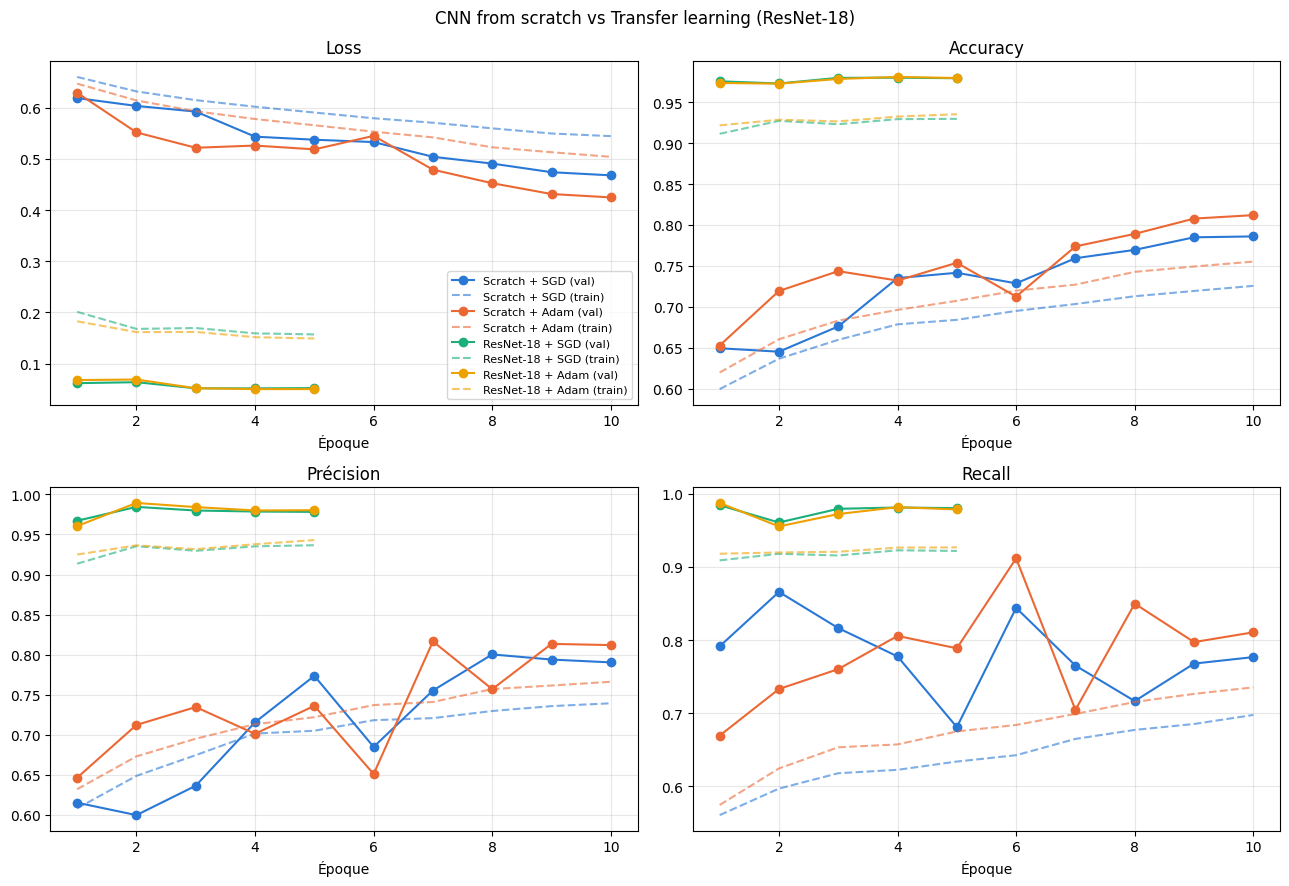

In [20]:
import matplotlib.pyplot as plt

os.makedirs(SAVE_DIR + '/figures', exist_ok=True)

historiques = {
    'Scratch + SGD':  hist_scratch_sgd,
    'Scratch + Adam': hist_scratch_adam,
    'ResNet-18 + SGD':  hist_tl_sgd,
    'ResNet-18 + Adam': hist_tl_adam,
}
couleurs = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
metriques = [('loss', 'Loss'), ('accuracy', 'Accuracy'), ('precision', 'Précision'), ('recall', 'Recall')]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (m, titre) in zip(axes.flat, metriques):
    for (nom, h), c in zip(historiques.items(), couleurs):
        ax.plot(h['epoch'], h['val_' + m],   color=c, marker='o', label=nom + ' (val)')
        ax.plot(h['epoch'], h['train_' + m], color=c, linestyle='--', alpha=0.6, label=nom + ' (train)')
    ax.set_title(titre)
    ax.set_xlabel('Époque')
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8)
plt.suptitle('CNN from scratch vs Transfer learning (ResNet-18)')
plt.tight_layout()
plt.savefig(SAVE_DIR + '/figures/courbes.png', dpi=120)
plt.show()

### Interprétation des courbes

**Convergence.** L'écart entre les deux approches est visible dès la première époque : les modèles en transfer learning atteignent environ 97,5 % d'accuracy de validation, alors que le CNN from scratch démarre autour de 65 %. Le réseau pré-entraîné dispose déjà de caractéristiques visuelles pertinentes : seul le classifieur final doit être appris. Le CNN from scratch, lui, doit tout apprendre à partir des 18 000 images d'entraînement, et sa loss de validation continue de diminuer à la dixième époque, signe qu'il n'a pas encore convergé.

**Performance.** Le transfer learning atteint environ 98 % d'accuracy de validation, contre 78,6 % (SGD) et 81,2 % (Adam) pour le CNN from scratch, soit un écart d'environ 17 points, obtenu en deux fois moins d'époques et en n'entraînant que 132 000 paramètres.

**Stabilité.** Les courbes de précision et de recall du CNN from scratch oscillent fortement d'une époque à l'autre (par exemple, un recall de 0,91 à l'époque 6 pour Adam, puis de 0,70 à l'époque 7) : le modèle hésite encore et penche tantôt vers la classe « chien », tantôt vers la classe « chat ». Les courbes du transfer learning sont au contraire stables et équilibrées (précision et recall proches de 0,98).

**Optimiseurs.** Pour le CNN from scratch, Adam converge plus vite que SGD et atteint une meilleure performance finale. Pour le transfer learning, les deux optimiseurs donnent des résultats quasiment identiques : lorsque le point de départ est déjà très bon, le choix de l'optimiseur a peu d'influence.

**Sur-apprentissage.** Pour toutes les configurations, les performances de validation sont supérieures à celles d'entraînement. Ce n'est pas une anomalie : pendant l'entraînement, les images sont modifiées aléatoirement (augmentation de données) et le Dropout désactive une partie des neurones, ce qui rend la tâche plus difficile qu'en validation. Aucun signe de sur-apprentissage n'est observé.

## 7. Évaluation finale sur le jeu de test

Pour chaque expérience, nous retenons la configuration ayant obtenu la meilleure accuracy de validation : Adam pour le CNN from scratch (81,2 %) et Adam pour ResNet-18 (98,1 %). Les poids sauvegardés (fichiers .pt) sont rechargés dans des modèles nouvellement créés, puis évalués une seule fois sur le jeu de test (2 500 images jamais utilisées auparavant). Les matrices de confusion permettent d'analyser la répartition des erreurs entre les deux classes.

                             Accuracy  Précision  Recall
A : CNN from scratch (Adam)    0.7932     0.7982  0.7848
B : ResNet-18 (Adam)           0.9820     0.9808  0.9832


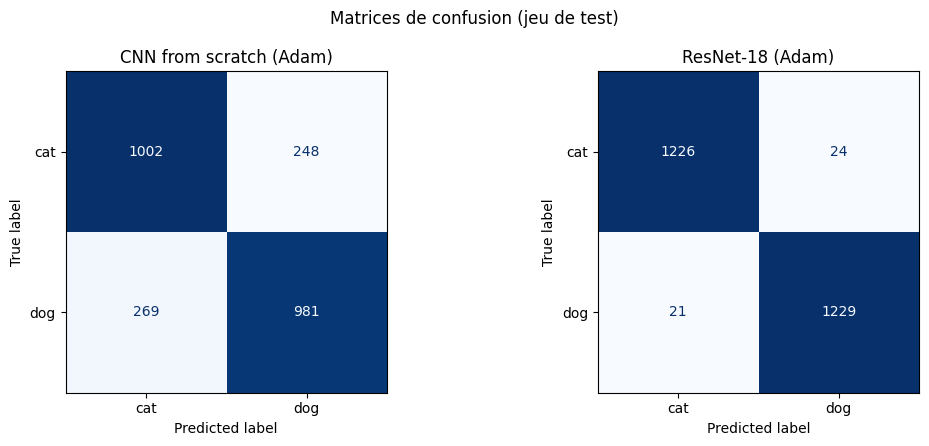

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluer_sur_test(model, nom):

    chemin = f'{SAVE_DIR}/checkpoints/{nom}.pt'
    model.load_state_dict(torch.load(chemin, map_location=device))
    model.eval()

    vrais, predits = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            sorties = model(images.to(device))
            vrais.extend(labels.numpy())
            predits.extend(sorties.argmax(1).cpu().numpy())
    return np.array(vrais), np.array(predits)


vrais_A, pred_A = evaluer_sur_test(ScratchCNN().to(device), 'scratch_adam')
vrais_B, pred_B = evaluer_sur_test(build_resnet().to(device), 'tl_adam')


resultats = pd.DataFrame({
    'Accuracy':  [accuracy_score(vrais_A, pred_A),  accuracy_score(vrais_B, pred_B)],
    'Précision': [precision_score(vrais_A, pred_A), precision_score(vrais_B, pred_B)],
    'Recall':    [recall_score(vrais_A, pred_A),    recall_score(vrais_B, pred_B)],
}, index=['A : CNN from scratch (Adam)', 'B : ResNet-18 (Adam)'])
resultats.to_csv(SAVE_DIR + '/results/test_results.csv')
print(resultats.round(4))


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (titre, v, p) in zip(axes, [('CNN from scratch (Adam)', vrais_A, pred_A),
                                    ('ResNet-18 (Adam)', vrais_B, pred_B)]):
    ConfusionMatrixDisplay(confusion_matrix(v, p), display_labels=['cat', 'dog']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(titre)
plt.suptitle('Matrices de confusion (jeu de test)')
plt.tight_layout()
plt.savefig(SAVE_DIR + '/figures/matrices_confusion.png', dpi=120)
plt.show()

### Résultats sur le jeu de test

| Modèle | Accuracy | Précision | Recall |
|---|---|---|---|
| A : CNN from scratch (Adam) | 79,32 % | 79,82 % | 78,48 % |
| B : ResNet-18, transfer learning (Adam) | **98,20 %** | **98,08 %** | **98,32 %** |

Les performances sur le jeu de test sont très proches de celles obtenues en validation (81,2 % et 98,1 %), ce qui confirme que les modèles généralisent correctement à des images jamais rencontrées, et que la sélection des modèles sur l'ensemble de validation n'a pas introduit de biais.

Les matrices de confusion montrent que le CNN from scratch commet 517 erreurs sur 2 500 images (248 chats classés comme chiens et 269 chiens classés comme chats), contre seulement 45 erreurs pour ResNet-18 (24 et 21), soit onze fois moins. Dans les deux cas, les erreurs sont réparties de manière équilibrée entre les deux classes : aucun des modèles ne présente de biais systématique en faveur de l'une d'elles.

Le transfert d'apprentissage apporte ainsi un gain de près de 19 points d'accuracy, tout en nécessitant deux fois moins d'époques d'entraînement et en n'entraînant qu'environ 1 % des paramètres du réseau.

Nombre d'erreurs ResNet-18 : 45


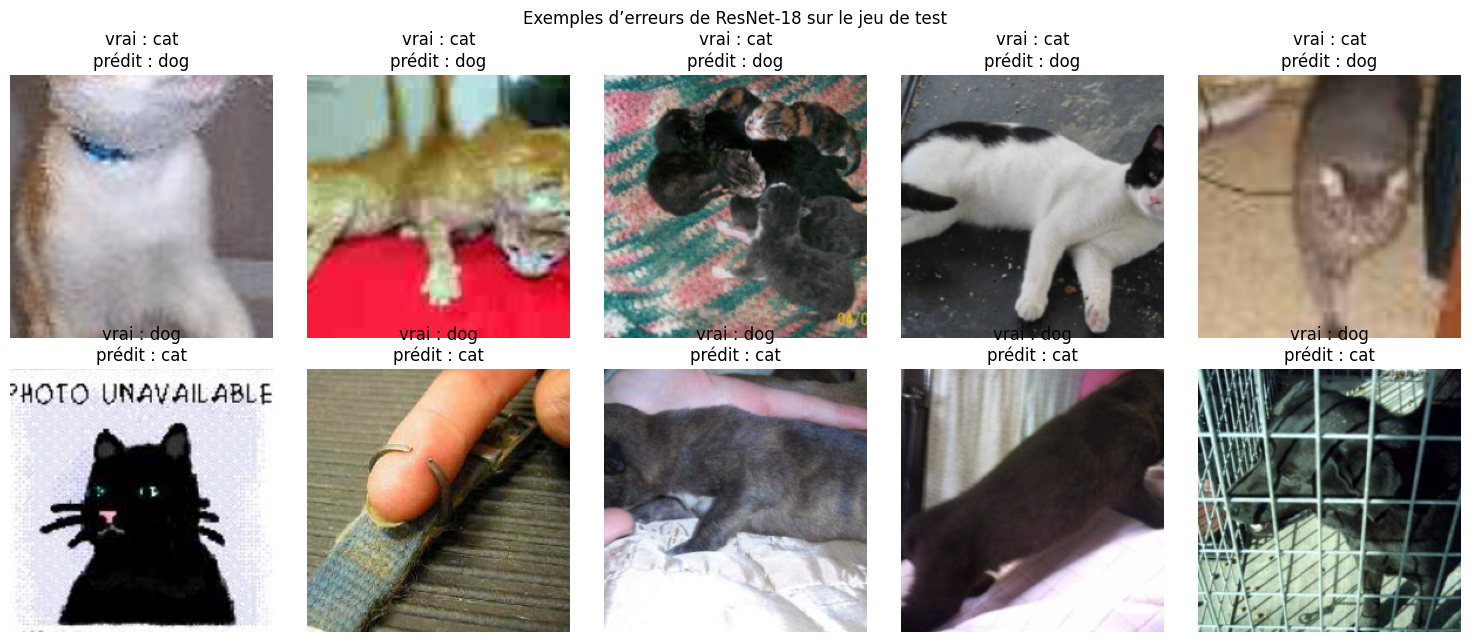

In [25]:
MEAN_np, STD_np = np.array(MEAN), np.array(STD)
classes = ['cat', 'dog']

erreurs = np.where(vrais_B != pred_B)[0]
print("Nombre d'erreurs ResNet-18 :", len(erreurs))

fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
erreurs_mix = np.concatenate([erreurs[vrais_B[erreurs] == 0][:5], erreurs[vrais_B[erreurs] == 1][:5]])
for ax, i in zip(axes.flat, erreurs_mix):
    image, _ = test_data[i]
    image = image.numpy().transpose(1, 2, 0) * STD_np + MEAN_np
    ax.imshow(np.clip(image, 0, 1))
    ax.set_title(f"vrai : {classes[vrais_B[i]]}\nprédit : {classes[pred_B[i]]}")
    ax.axis('off')
plt.suptitle('Exemples d’erreurs de ResNet-18 sur le jeu de test')
plt.tight_layout()
plt.savefig(SAVE_DIR + '/figures/erreurs_resnet.png', dpi=110)
plt.show()

### Analyse des erreurs typiques

Les dix exemples ci-dessus (cinq chats et cinq chiens mal classés par ResNet-18) font apparaître plusieurs causes récurrentes :

- **Qualité de l'image** : plusieurs images sont floues, pixellisées ou très sombres (chiots au pelage noir, chien dans une cage mal éclairée), ce qui prive le modèle des détails nécessaires.
- **Absence du visage** : lorsque la tête de l'animal est coupée ou non visible, le modèle perd l'indice le plus discriminant entre un chat et un chien. Une des images ne montre même qu'un doigt et des griffes en gros plan.
- **Éléments de contexte trompeurs** : des chats portant un collier ou photographiés dans une cage sont classés comme chiens. Le modèle semble s'appuyer en partie sur l'arrière-plan et les accessoires, et pas uniquement sur l'animal.
- **Scènes complexes et poses inhabituelles** : une portée de chatons entremêlés, ou des chats allongés sur le côté, présentent une silhouette peu typique.
- **Erreurs d'étiquetage du jeu de données** : une image rangée dans la classe « dog » est en réalité une vignette « PHOTO UNAVAILABLE » représentant un dessin de chat. Dans ce cas, la prédiction du modèle (« cat ») est correcte : c'est l'étiquette qui est fausse.

La plupart de ces erreurs concernent des images réellement ambiguës, de mauvaise qualité, voire mal étiquetées, qu'un observateur humain aurait lui-même du mal à classer. Sur des images « normales », le modèle ne se trompe quasiment pas. Une partie des 45 erreurs est donc imputable au bruit présent dans les données plutôt qu'au modèle.